## 1 — Imports & setup

In [1]:
import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
import mlflow.xgboost
import matplotlib.pyplot as plt
import shap
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import xgboost as xgb
import lightgbm as lgb

# Load features
X = pd.read_csv("./data/processed/X.csv")
y = pd.read_csv("./data/processed/y.csv").squeeze()

print(f"X: {X.shape}, y: {y.shape}")
print(f"Cancellation rate: {y.mean():.3f}")

# Train/test split — stratified to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

X: (86372, 59), y: (86372,)
Cancellation rate: 0.275
Train: (69097, 59), Test: (17275, 59)


## 2 — Start MLflow & set experiment

In [2]:
# Set tracking URI — saves runs locally in your project folder
mlflow.set_tracking_uri("./mlruns")
mlflow.set_experiment("australian-hotels-cancellation")

print("MLflow tracking URI:", mlflow.get_tracking_uri())
print("Experiment set: australian-hotels-cancellation")

MLflow tracking URI: ./mlruns
Experiment set: australian-hotels-cancellation


## 3 — Helper: evaluate & log to MLflow

In [3]:
def evaluate_model(model, X_test, y_test):
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    return {
        "accuracy": round(accuracy_score(y_test, y_pred), 4),
        "f1":       round(f1_score(y_test, y_pred), 4),
        "auc_roc":  round(roc_auc_score(y_test, y_proba), 4),
        "f1_macro": round(f1_score(y_test, y_pred, average="macro"), 4),
    }

def log_run(run_name, model, params, metrics, X_train, feature_names):
    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(params)
        mlflow.log_metrics(metrics)
        mlflow.sklearn.log_model(model, artifact_path="model")

        # Log confusion matrix as artifact
        fig, ax = plt.subplots(figsize=(5, 4))
        ConfusionMatrixDisplay.from_predictions(
            y_test, model.predict(X_test), ax=ax,
            display_labels=["Not Cancelled","Cancelled"], cmap="Blues"
        )
        ax.set_title(f"Confusion Matrix — {run_name}")
        fig.tight_layout()
        fig.savefig(f"./reports/figures/cm_{run_name.replace(' ','_')}.png", dpi=150)
        mlflow.log_artifact(f"./reports/figures/cm_{run_name.replace(' ','_')}.png")
        plt.close()

        print(f"\n{'='*45}")
        print(f"  Run: {run_name}")
        for k, v in metrics.items():
            print(f"  {k:12s}: {v:.4f}")
        print(f"{'='*45}")

## 4 — Baseline: Logistic Regression

In [4]:
lr_params = {
    "model_type": "LogisticRegression",
    "C": 1.0,
    "max_iter": 1000,
    "class_weight": "balanced",
    "solver": "lbfgs"
}

lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        C=lr_params["C"],
        max_iter=lr_params["max_iter"],
        class_weight=lr_params["class_weight"],
        solver=lr_params["solver"],
        random_state=42
    ))
])

lr_pipeline.fit(X_train, y_train)
lr_metrics = evaluate_model(lr_pipeline, X_test, y_test)
log_run("Logistic Regression Baseline", lr_pipeline, lr_params, lr_metrics, X_train, X.columns)

2026/05/31 08:12:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/31 08:12:56 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



  Run: Logistic Regression Baseline
  accuracy    : 0.7278
  f1          : 0.6075
  auc_roc     : 0.8237
  f1_macro    : 0.6996


## 5 — XGBoost

In [5]:
xgb_params = {
    "model_type":       "XGBoost",
    "n_estimators":     500,
    "max_depth":        6,
    "learning_rate":    0.05,
    "subsample":        0.8,
    "colsample_bytree": 0.8,
    "scale_pos_weight": (y_train == 0).sum() / (y_train == 1).sum(),  # handles imbalance
    "eval_metric":      "auc",
    "random_state":     42
}

xgb_model = xgb.XGBClassifier(
    n_estimators      = xgb_params["n_estimators"],
    max_depth         = xgb_params["max_depth"],
    learning_rate     = xgb_params["learning_rate"],
    subsample         = xgb_params["subsample"],
    colsample_bytree  = xgb_params["colsample_bytree"],
    scale_pos_weight  = xgb_params["scale_pos_weight"],
    eval_metric       = xgb_params["eval_metric"],
    random_state      = xgb_params["random_state"],
    use_label_encoder = False,
    verbosity         = 0
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

xgb_metrics = evaluate_model(xgb_model, X_test, y_test)
log_run("XGBoost", xgb_model, xgb_params, xgb_metrics, X_train, X.columns)

2026/05/31 08:14:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/31 08:14:52 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



  Run: XGBoost
  accuracy    : 0.7864
  f1          : 0.6695
  auc_roc     : 0.8688
  f1_macro    : 0.7558


## 6 — LightGBM

In [6]:
lgb_params = {
    "model_type":      "LightGBM",
    "n_estimators":    500,
    "max_depth":       6,
    "learning_rate":   0.05,
    "num_leaves":      63,
    "subsample":       0.8,
    "class_weight":    "balanced",
    "random_state":    42
}

lgb_model = lgb.LGBMClassifier(
    n_estimators  = lgb_params["n_estimators"],
    max_depth     = lgb_params["max_depth"],
    learning_rate = lgb_params["learning_rate"],
    num_leaves    = lgb_params["num_leaves"],
    subsample     = lgb_params["subsample"],
    class_weight  = lgb_params["class_weight"],
    random_state  = lgb_params["random_state"],
    verbose       = -1
)

lgb_model.fit(X_train, y_train)
lgb_metrics = evaluate_model(lgb_model, X_test, y_test)
log_run("LightGBM", lgb_model, lgb_params, lgb_metrics, X_train, X.columns)

2026/05/31 08:15:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/31 08:15:51 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



  Run: LightGBM
  accuracy    : 0.7848
  f1          : 0.6674
  auc_roc     : 0.8681
  f1_macro    : 0.7542


## 7 — Compare all runs & pick champion

In [7]:
# Pull all runs from MLflow
client = mlflow.tracking.MlflowClient()
experiment = client.get_experiment_by_name("australian-hotels-cancellation")
runs = client.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=["metrics.auc_roc DESC"]
)

print(f"\n{'Run Name':<35} {'AUC-ROC':>8} {'F1':>8} {'Accuracy':>9}")
print("-" * 65)
for r in runs:
    name = r.data.tags.get("mlflow.runName", r.info.run_id[:8])
    auc  = r.data.metrics.get("auc_roc", 0)
    f1   = r.data.metrics.get("f1", 0)
    acc  = r.data.metrics.get("accuracy", 0)
    print(f"{name:<35} {auc:>8.4f} {f1:>8.4f} {acc:>9.4f}")

# Champion = top AUC run
champion_run = runs[0]
champion_name = champion_run.data.tags.get("mlflow.runName")
print(f"\n🏆 Champion model: {champion_name}")
print(f"   AUC-ROC: {champion_run.data.metrics['auc_roc']:.4f}")


Run Name                             AUC-ROC       F1  Accuracy
-----------------------------------------------------------------
XGBoost                               0.8688   0.6695    0.7864
XGBoost                               0.8688   0.6695    0.7864
XGBoost                               0.8688   0.6695    0.7864
LightGBM                              0.8681   0.6674    0.7848
LightGBM                              0.8681   0.6674    0.7848
LightGBM                              0.8681   0.6674    0.7848
Logistic Regression Baseline          0.8237   0.6075    0.7278
Logistic Regression Baseline          0.8237   0.6075    0.7278
Logistic Regression Baseline          0.8237   0.6075    0.7278

🏆 Champion model: XGBoost
   AUC-ROC: 0.8688


## 8 — SHAP explainability on champion

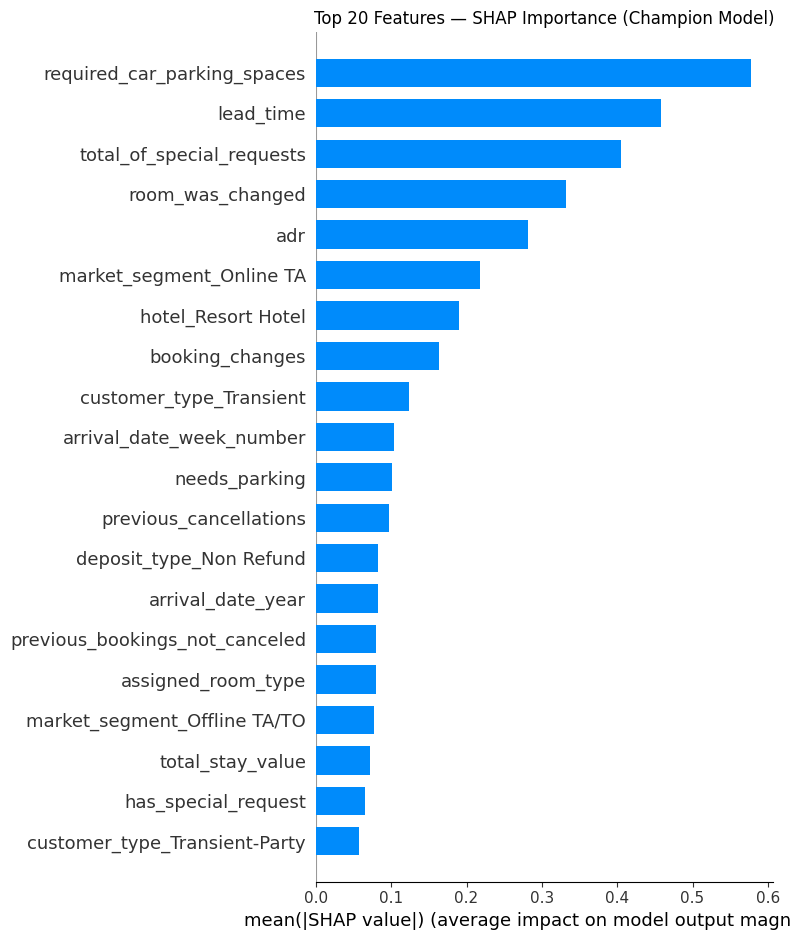

Saved: reports/figures/shap_summary.png


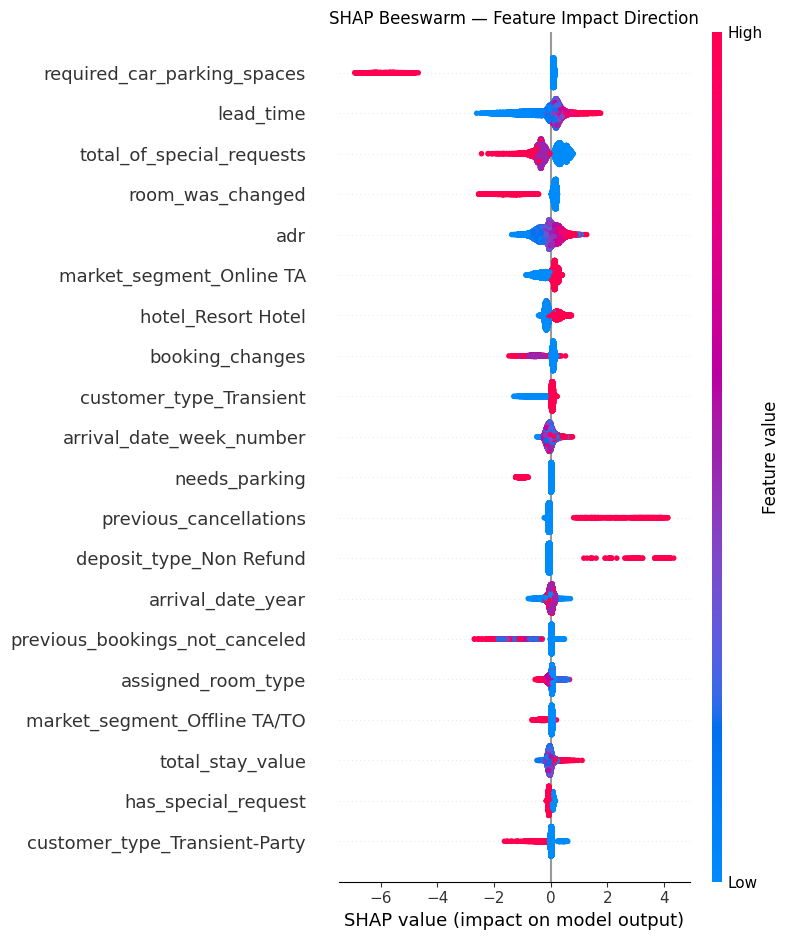

In [8]:
# Use XGBoost or LightGBM — whichever won
# Adjust this line to whichever model was champion
champion_model = xgb_model  # or lgb_model

explainer   = shap.TreeExplainer(champion_model)
shap_values = explainer.shap_values(X_test)

# Summary plot — most important features
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, plot_type="bar",
                  max_display=20, show=False)
plt.title("Top 20 Features — SHAP Importance (Champion Model)")
plt.tight_layout()
plt.savefig("./reports/figures/shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: reports/figures/shap_summary.png")

# Beeswarm — shows direction of impact
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, max_display=20, show=False)
plt.title("SHAP Beeswarm — Feature Impact Direction")
plt.tight_layout()
plt.savefig("./reports/figures/shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

## 9 — Register champion in MLflow Model Registry & save to disk

In [9]:
import pickle, json

# Register in MLflow
champion_run_id = champion_run.info.run_id
model_uri = f"runs:/{champion_run_id}/model"

registered = mlflow.register_model(model_uri, "hotel-cancellation-champion")
print(f"Registered model: {registered.name} v{registered.version}")

# Also save to disk for FastAPI (Phase 5)
with open("./models/registry/champion_model.pkl", "wb") as f:
    pickle.dump(champion_model, f)

# Save champion metadata
meta = {
    "run_id":       champion_run_id,
    "run_name":     champion_name,
    "auc_roc":      champion_run.data.metrics["auc_roc"],
    "f1":           champion_run.data.metrics["f1"],
    "accuracy":     champion_run.data.metrics["accuracy"],
    "feature_count": X_train.shape[1]
}
with open("./models/registry/champion_meta.json", "w") as f:
    json.dump(meta, f, indent=2)

print("\nSaved to models/registry/:")
print("  champion_model.pkl")
print("  champion_meta.json")

Registered model 'hotel-cancellation-champion' already exists. Creating a new version of this model...
2026/05/31 08:21:34 WARNING mlflow.tracking._model_registry.fluent: Run with id 62c133d7cd2a4a7a9f8c3b9270104520 has no artifacts at artifact path 'model', registering model based on models:/m-3b7fca52a2284e0187b76c5662e3e202 instead


Registered model: hotel-cancellation-champion v3

Saved to models/registry/:
  champion_model.pkl
  champion_meta.json


Created version '3' of model 'hotel-cancellation-champion'.


##  10 — Launch MLflow UI

### Run this in a separate terminal (keep Jupyter open):

cd C:\Users\HB Laptop Store\Desktop\hotel_bookings


venv\Scripts\activate


mlflow ui --backend-store-uri mlruns --port 5000

Then open your browser at http://localhost:5000 — you'll see all 3 runs side by side with metrics, confusion matrices, and artifacts.

## 11 — Hyperparameter tuning with Optuna

In [10]:
pip install optuna

Note: you may need to restart the kernel to use updated packages.


In [11]:
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 300, 1000),
        "max_depth":         trial.suggest_int("max_depth", 3, 10),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight":  trial.suggest_int("min_child_weight", 1, 10),
        "gamma":             trial.suggest_float("gamma", 0.0, 1.0),
        "reg_alpha":         trial.suggest_float("reg_alpha", 0.0, 1.0),
        "reg_lambda":        trial.suggest_float("reg_lambda", 0.5, 2.0),
        "scale_pos_weight":  (y_train == 0).sum() / (y_train == 1).sum(),
        "use_label_encoder": False,
        "eval_metric":       "auc",
        "verbosity":         0,
        "random_state":      42,
    }

    model = xgb.XGBClassifier(**params)

    # 3-fold CV on training set — fast but reliable
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train,
                             cv=cv, scoring="roc_auc", n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42))
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nBest AUC-ROC (CV): {study.best_value:.4f}")
print(f"Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

  0%|          | 0/50 [00:00<?, ?it/s]


Best AUC-ROC (CV): 0.8662
Best params:
  n_estimators: 997
  max_depth: 10
  learning_rate: 0.020136131981438085
  subsample: 0.9401198111736042
  colsample_bytree: 0.8288364191534061
  min_child_weight: 3
  gamma: 0.6078819361471207
  reg_alpha: 0.5213961931257547
  reg_lambda: 1.4526301485094792


## 12 — Train tuned champion & log to MLflow

In [12]:
best = study.best_params
best["scale_pos_weight"] = (y_train == 0).sum() / (y_train == 1).sum()
best["use_label_encoder"] = False
best["eval_metric"]       = "auc"
best["verbosity"]         = 0
best["random_state"]      = 42

tuned_xgb = xgb.XGBClassifier(**best)
tuned_xgb.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              verbose=False)

tuned_metrics = evaluate_model(tuned_xgb, X_test, y_test)

# Log to MLflow
log_run("XGBoost Tuned (Optuna)", tuned_xgb,
        {**best, "model_type": "XGBoost_Tuned", "optuna_trials": 50},
        tuned_metrics, X_train, X.columns)

print("\nImprovement over baseline XGBoost:")
for k in tuned_metrics:
    delta = tuned_metrics[k] - xgb_metrics[k]
    arrow = "↑" if delta > 0 else "↓"
    print(f"  {k:12s}: {xgb_metrics[k]:.4f} → {tuned_metrics[k]:.4f}  {arrow}{abs(delta):.4f}")

2026/05/31 09:36:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/31 09:36:39 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



  Run: XGBoost Tuned (Optuna)
  accuracy    : 0.8008
  f1          : 0.6769
  auc_roc     : 0.8739
  f1_macro    : 0.7664

Improvement over baseline XGBoost:
  accuracy    : 0.7864 → 0.8008  ↑0.0144
  f1          : 0.6695 → 0.6769  ↑0.0074
  auc_roc     : 0.8688 → 0.8739  ↑0.0051
  f1_macro    : 0.7558 → 0.7664  ↑0.0106


## 13 — SHAP on tuned model & save final champion

In [ ]:
# SHAP
explainer   = shap.TreeExplainer(tuned_xgb)
shap_values = explainer.shap_values(X_test)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

plt.sca(axes[0])
shap.summary_plot(shap_values, X_test, plot_type="bar",
                  max_display=20, show=False)
axes[0].set_title("Top 20 Features — SHAP Importance")

plt.sca(axes[1])
shap.summary_plot(shap_values, X_test,
                  max_display=20, show=False)
axes[1].set_title("SHAP Impact Direction")

plt.tight_layout()
plt.savefig("./reports/figures/shap_tuned_champion.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: reports/figures/shap_tuned_champion.png")

## 14 — Overwrite champion with tuned model

In [ ]:
import pickle, json

# Save model
with open("../models/registry/champion_model.pkl", "wb") as f:
    pickle.dump(tuned_xgb, f)

# Save feature names (needed by FastAPI)
feature_names = list(X_train.columns)
with open("../models/registry/feature_names.json", "w") as f:
    json.dump(feature_names, f, indent=2)

# Save metadata
champion_meta = {
    "model_type":    "XGBoost_Tuned",
    "auc_roc":       tuned_metrics["auc_roc"],
    "f1":            tuned_metrics["f1"],
    "accuracy":      tuned_metrics["accuracy"],
    "feature_count": len(feature_names),
    "optuna_trials": 50,
    "threshold":     0.5,
    "trained_on":    str(pd.Timestamp.now().date()),
    "dataset_rows":  len(X_train)
}
with open("../models/registry/champion_meta.json", "w") as f:
    json.dump(champion_meta, f, indent=2)

print("Champion model locked:")
print(f"  AUC-ROC  : {tuned_metrics['auc_roc']:.4f}")
print(f"  F1       : {tuned_metrics['f1']:.4f}")
print(f"  Accuracy : {tuned_metrics['accuracy']:.4f}")
print(f"  Features : {len(feature_names)}")
print("\nSaved:")
print("  models/registry/champion_model.pkl")
print("  models/registry/feature_names.json")
print("  models/registry/champion_meta.json")